FIRST 5 ROWS
  Transaction ID                           Date  Customer ID  Gender  Age  \
0         T00001  2025-01-01 00:00:00.000000000         1102  Female   53   
1         T00002  2025-01-01 08:44:41.081081081         1179    Male   44   
2         T00003  2025-01-01 17:29:22.162162162         1092  Female   55   
3         T00004  2025-01-02 02:14:03.243243243         1014    Male   24   
4         T00005  2025-01-02 10:58:44.324324324         1106  Female   22   

  Product Category  Quantity  Price per Unit  Total Amount  
0             Home         1            2203          2203  
1      Electronics         1             465           465  
2      Electronics         3            3675         11025  
3      Electronics         3            4650         13950  
4         Clothing         1            4299          4299  

DATASET SHAPE
(1000, 9)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column   

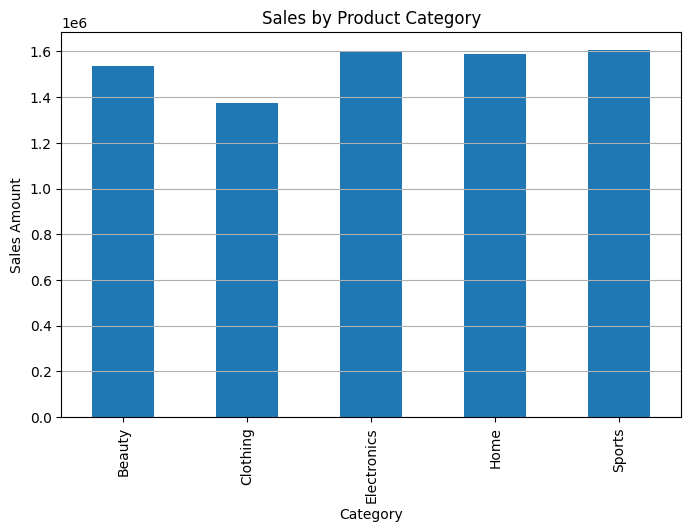


GENDER-WISE SALES
Gender
Female    3663964
Male      4036891
Name: Total Amount, dtype: int64


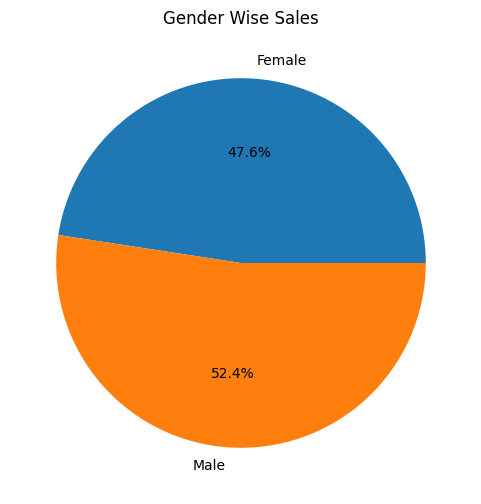


MONTHLY SALES
Month
April        657095
August       587101
December     773848
February     563245
January      686519
July         647385
June         592297
March        646220
May          689999
November     684960
October      531351
September    640835
Name: Total Amount, dtype: int64


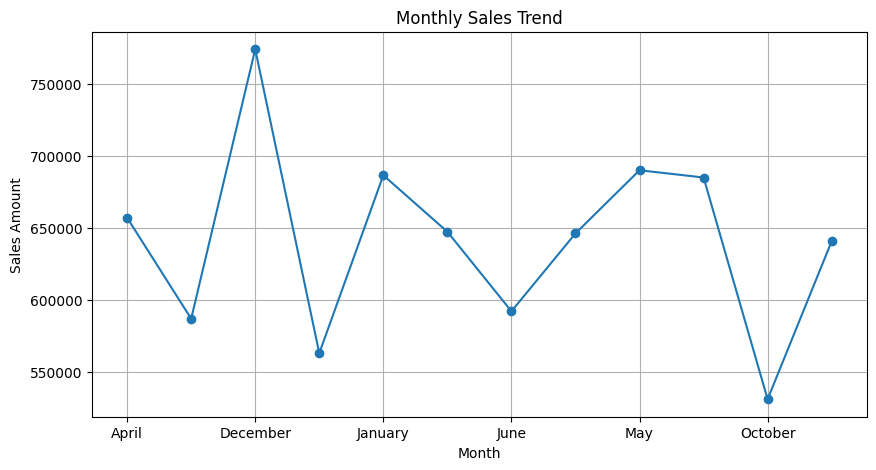


TOP 10 CUSTOMERS
Customer ID
1098    113392
1085    108555
1112    103279
1128     95362
1189     94209
1191     91930
1127     91523
1144     89310
1160     87204
1110     83103
Name: Total Amount, dtype: int64


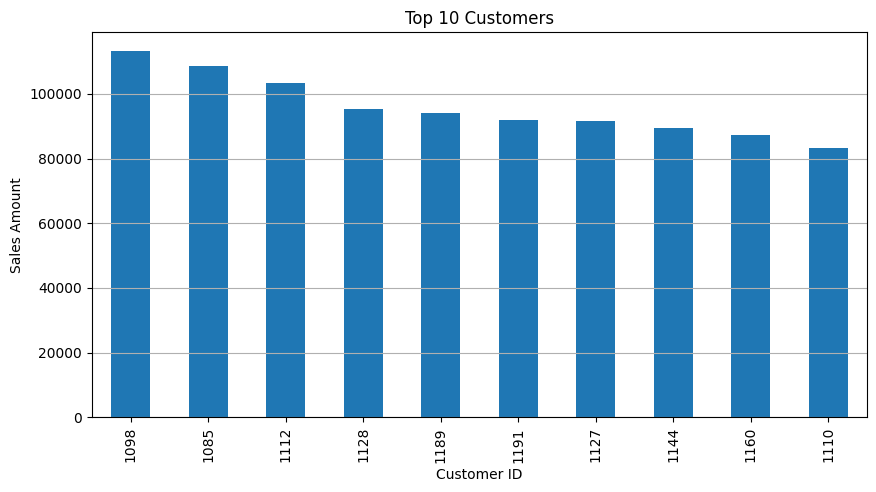


BEST SELLING CATEGORY: Sports
CATEGORY SALES: 1604081


In [2]:

# RETAIL SALES PERFORMANCE ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("retail_sales_dataset.csv")

# DATA OVERVIEW


print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# TOTAL SALES

total_sales = df["Total Amount"].sum()
print("\nTOTAL SALES:", total_sales)

# TOTAL ORDERS

total_orders = len(df)
print("TOTAL ORDERS:", total_orders)

# SALES BY PRODUCT CATEGORY

category_sales = df.groupby("Product Category")["Total Amount"].sum()

print("\nSALES BY CATEGORY")
print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.grid(axis="y")
plt.show()

# GENDER-WISE SALES

gender_sales = df.groupby("Gender")["Total Amount"].sum()

print("\nGENDER-WISE SALES")
print(gender_sales)

plt.figure(figsize=(6,6))
gender_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Wise Sales")
plt.ylabel("")
plt.show()

# MONTHLY SALES TREND

df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()

monthly_sales = df.groupby("Month")["Total Amount"].sum()

print("\nMONTHLY SALES")
print(monthly_sales)

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()
# TOP 10 CUSTOMERS

customer_sales = (
    df.groupby("Customer ID")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 CUSTOMERS")
print(customer_sales)

plt.figure(figsize=(10,5))
customer_sales.plot(kind="bar")
plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Sales Amount")
plt.grid(axis="y")
plt.show()

# BEST SELLING CATEGORY

best_category = category_sales.idxmax()
best_sales = category_sales.max()

print("\nBEST SELLING CATEGORY:", best_category)
print("CATEGORY SALES:", best_sales)

